*Aprendizaje Profundo*  
*Tarea 6 -* Clasificacion de numeros con Redes Neuronales  
*Autor:* Ing. Daniel Eduardo González Alvarado  
*Profesor:* Dr. Sebastian Salazar

$$I(x,y) * K= \sum_{i=-N}^N\sum_{j=-N}^N I(x+i, y +j) \times K(-i , -j)$$

# Importar Librerias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tkinter as tk
from PIL import Image, ImageDraw, ImageFilter, ImageChops, ImageOps

In [43]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Train: ",x_train.shape,"Test:" ,x_test.shape)

x_train = x_train.reshape(-1, 28*28).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 28*28).astype("float32") / 255.0
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

Train:  (60000, 28, 28) Test: (10000, 28, 28)
(60000, 784) (10000, 784)
(60000,) (10000,)


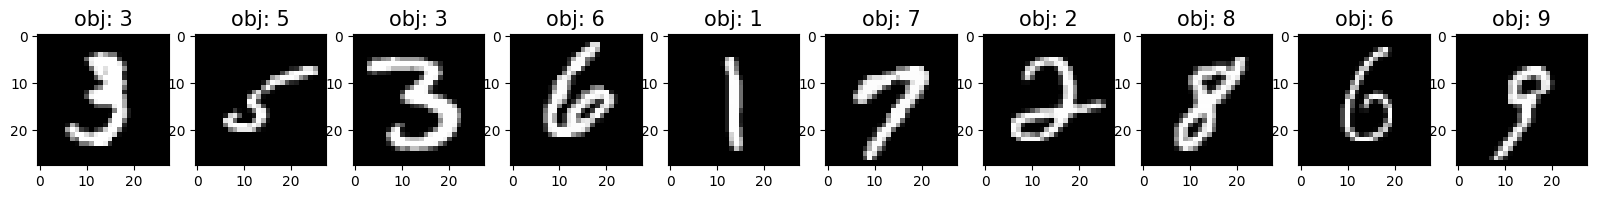

In [3]:
plt.figure(figsize=(20,4))

inicial = 10
for index, (imagen, etiqueta) in enumerate(zip(x_train[inicial:inicial+10], y_train[inicial:inicial+10])):
    plt.subplot(1, 10, index + 1)
    plt.imshow(np.reshape(imagen, (28,28)), cmap=plt.cm.gray)
    plt.title('obj: ' + str(etiqueta), fontsize=15)

# Modelo RNN Perceptron

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),       
    tf.keras.layers.Dense(128, activation="relu"),  
    tf.keras.layers.Dense(10, activation="softmax")
])
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8206 - loss: 0.6514 - val_accuracy: 0.9507 - val_loss: 0.1804
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9464 - loss: 0.1911 - val_accuracy: 0.9635 - val_loss: 0.1269
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9637 - loss: 0.1293 - val_accuracy: 0.9727 - val_loss: 0.1029
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9717 - loss: 0.1024 - val_accuracy: 0.9725 - val_loss: 0.0974
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9765 - loss: 0.0827 - val_accuracy: 0.9748 - val_loss: 0.0861


In [46]:
model.save("mnist_perceptron.h5")

# Interfaz

In [47]:
model = tf.keras.models.load_model("mnist_perceptron.h5")

In [48]:
def start_draw(event):
    global last_x, last_y
    last_x, last_y = event.x, event.y

In [49]:
def draw_line(event):
    """Dibuja en Canvas y en PIL."""
    global last_x, last_y, draw
    if last_x is None or last_y is None:
        last_x, last_y = event.x, event.y

    # 1) Dibuja en la UI
    canvas.create_line(last_x, last_y, event.x, event.y,
                       width=BRUSH_WIDTH, fill="white",
                       capstyle=tk.ROUND, smooth=True)

    # 2) Dibuja en la imagen PIL (MUY IMPORTANTE: fill=255)
    draw.line([last_x, last_y, event.x, event.y],
              fill=255, width=BRUSH_WIDTH)  # 255 = blanco

    last_x, last_y = event.x, event.y

In [50]:
def clear_canvas():
    """Limpia todo y RECREA draw para la nueva img."""
    global img, draw, last_x, last_y
    canvas.delete("all")
    img = Image.new("L", (CANVAS_SIZE, CANVAS_SIZE), color=0)
    draw = ImageDraw.Draw(img)  # <- no olvides esto
    last_x, last_y = None, None
    lbl_result.config(text="Dibuja un dígito y presiona Predecir")

In [51]:
def preprocess_for_mnist(image_L):
    bbox = image_L.getbbox()
    if bbox is None:
        return np.zeros((28, 28), dtype=np.float32)
    crop = image_L.crop(bbox)

    w, h = crop.size
    margin = 4
    m = max(w, h)
    sq = Image.new("L", (m + 2*margin, m + 2*margin), 0)
    sq.paste(crop, ((sq.width - w)//2, (sq.height - h)//2))

    W, H = sq.size
    scale = 20 / max(W, H) if max(W, H) > 20 else 1.0
    new_size = (max(1, int(round(W*scale))), max(1, int(round(H*scale))))
    digit = sq.resize(new_size, Image.LANCZOS)

    canvas = Image.new("L", (28, 28), 0)
    ox = (28 - digit.width) // 2
    oy = (28 - digit.height) // 2
    canvas.paste(digit, (ox, oy))

    a = np.asarray(canvas, dtype=np.float32)
    if a.max() > 0:
        wght = a / 255.0
        yv, xv = np.indices((28, 28))
        cx = (xv * wght).sum() / (wght.sum() + 1e-8)
        cy = (yv * wght).sum() / (wght.sum() + 1e-8)
        dx = int(round(14 - cx))
        dy = int(round(14 - cy))
        canvas = ImageChops.offset(canvas, dx, dy)

    return np.asarray(canvas, dtype=np.float32) / 255.0

In [52]:
def prepare_for_model(arr28, model):
    """
    Adapta (28,28) -> lo que pida el modelo (784) o (28,28,1).
    Soporta:
      - perceptrón clásico: input_shape == (None, 784)
      - modelos con imagen: (None, 28, 28, 1) o (None, 28, 28)
    """
    ishape = model.input_shape
    arr28 = arr28.astype("float32")

    if ishape == (None, 784):
        return arr28.reshape(1, 28*28)  # aplanado para perceptrón
    elif len(ishape) == 4 and ishape[1:4] == (28, 28, 1):
        return arr28.reshape(1, 28, 28, 1)  # agrega canal
    elif len(ishape) == 3 and ishape[1:3] == (28, 28):
        return arr28.reshape(1, 28, 28)  # sin canal
    else:
        # fallback razonable: intenta (1,28,28,1)
        return arr28.reshape(1, 28, 28, 1)

In [53]:
def predict_digit():
    arr28 = preprocess_for_mnist(img)
    x = prepare_for_model(arr28, model) 
    probs = model.predict(x, verbose=0)[0]
    pred = int(np.argmax(probs))
    conf = float(probs[pred])
    lbl_result.config(text=f"Predicción: {pred}  (confianza: {conf:.2%})")

In [54]:
from PIL import ImageTk, Image
import numpy as np
import time
import os
def _show_arr28_in_window(arr28):
    """
    Muestra el array (28,28) en una ventana Tkinter, reescalado a 280x280 con zoom por píxel.
    arr28: float en [0,1] o uint8 en [0,255]
    """
    # convertir a uint8 0..255
    if arr28.dtype != np.uint8:
        arr = (np.clip(arr28, 0, 1) * 255).astype(np.uint8)
    else:
        arr = arr28

    im = Image.fromarray(arr, mode="L")
    im_big = im.resize((280, 280), Image.NEAREST)  # zoom duro para ver píxeles

    top = tk.Toplevel(root)
    top.title("Entrada 28×28 al modelo")
    # mantener referencia a PhotoImage para que no lo recoja el GC
    top.imgtk = ImageTk.PhotoImage(im_big)
    lbl = tk.Label(top, image=top.imgtk)
    lbl.pack(padx=10, pady=10)

def preview_processed():
    """
    Preprocesa el canvas actual y lo muestra como lo verá el modelo.
    """
    arr28 = preprocess_for_mnist(img)  # (28,28) float32 en [0,1]
    _show_arr28_in_window(arr28)

def save_processed(label_text=""):
    """
    (Opcional) Guarda el 28x28 actual como .npy y .png para fine-tuning.
    Cambia 'label_text' por la etiqueta correcta antes de llamar.
    """
    arr28 = preprocess_for_mnist(img)
    os.makedirs("samples", exist_ok=True)
    ts = int(time.time())
    base = f"samples/{label_text}_{ts}" if label_text else f"samples/{ts}"
    np.save(base + ".npy", arr28)

    # también como PNG para revisar a ojo
    im = Image.fromarray((arr28 * 255).astype(np.uint8), mode="L")

In [59]:
CANVAS_SIZE = 200
BRUSH_WIDTH = 17

root = tk.Tk()
root.title("Reconocimiento de numeros (Perceptrón)")
canvas = tk.Canvas(root, width=CANVAS_SIZE, height=CANVAS_SIZE, bg="black")
canvas.grid(row=0, column=0, columnspan=3, padx=10, pady=10)

img = Image.new("L", (CANVAS_SIZE, CANVAS_SIZE), color=0) 
draw = ImageDraw.Draw(img)

last_x, last_y = None, None

In [60]:
canvas.bind("<ButtonPress-1>", start_draw)
canvas.bind("<B1-Motion>", draw_line)

# Botones y etiqueta de resultado
btn_clear = tk.Button(root, text="Borrar", command=clear_canvas)
btn_clear.grid(row=1, column=0, padx=10, pady=5, sticky="ew")

btn_predict = tk.Button(root, text="Predecir", command=predict_digit)
btn_predict.grid(row=1, column=1, padx=10, pady=5, sticky="ew")

btn_preview = tk.Button(root, text="Ver 28×28", command=preview_processed)
btn_preview.grid(row=2, column=0, padx=10, pady=5, sticky="ew", columnspan=2)

lbl_result = tk.Label(root, text="Dibuja un dígito y presiona Predecir",
                      font=("Arial", 12))
lbl_result.grid(row=1, column=2, padx=10, pady=5)

root.mainloop()